In [1]:
%load_ext autoreload
%autoreload 2

In [1]:
import scanpy as sc
import pandas as pd
import numpy as np
import os
import torch

## preprocess and embedding

In [2]:
from src.preprocessing import pp
from sklearn.model_selection import train_test_split
import scvi

In [3]:
filePath = './data/zesta/zebrafish_processed.h5ad'
adata = sc.read_h5ad(filePath)
#adata = adata[adata.obs.sample(frac=0.01, random_state=42).index].to_memory()
#print(adata)
print(adata.obs["condition"].value_counts())

condition
control_control_48    204327
control_control_36    158564
control_control_72    115985
control_control_24     80761
hgfa_control_72        77277
                       ...  
tbxta_control_18       11681
wnt3a_wnt8_18          11184
cdx4_cdx1a_24           9311
tbxta_control_24        8684
wnt3a_wnt8_24           4736
Name: count, Length: 76, dtype: int64


In [8]:

# 假设 adata 已经读取
# filePath = './data/norman.h5ad'
# adata = sc.read_h5ad(filePath)

def parse_condition(cond_str):
    """
    解析 condition 字符串，返回 (type, name, gene_list)
    """
    # 1. 处理纯 Control
    if cond_str == 'ctrl':
        return 'control', 'control', []
    
    # 2. 按照 '+' 拆分
    parts = cond_str.split('+')
    
    # 移除 'ctrl' 字符串，只保留实际基因
    genes = [g for g in parts if g != 'ctrl']
    
    if len(genes) == 0:
        # 这种情况通常是 'ctrl+ctrl'，依然视为 control
        return 'control', 'control', []
    elif len(genes) == 1:
        # 单扰动 (例如 'KLF1+ctrl' -> ['KLF1'])
        return 'single', genes[0], genes
    elif len(genes) == 2:
        # 双扰动 (例如 'TBX3+TBX2' -> ['TBX3', 'TBX2'])
        # 为了避免 A+B 和 B+A 被视为不同，通常建议排序
        sorted_genes = sorted(genes)
        return 'double', f"{sorted_genes[0]}+{sorted_genes[1]}", sorted_genes
    else:
        # 极其罕见的三基因或更多，按需处理
        return 'other', '+'.join(genes), genes

In [10]:
parsed_data = adata.obs['condition'].astype(str).apply(parse_condition)

# 将结果解压到新的列表中
pert_types = [x[0] for x in parsed_data]
pert_names = [x[1] for x in parsed_data]
pert_genes_list = [x[2] for x in parsed_data]

In [11]:
adata.obs['pert_type'] = pert_types
adata.obs['pert_name'] = pert_names 

# 把双扰动的两个基因分开存到列里
adata.obs['gene1'] = [genes[0] if len(genes) > 0 else np.nan for genes in pert_genes_list]
adata.obs['gene2'] = [genes[1] if len(genes) > 1 else np.nan for genes in pert_genes_list]

In [12]:
all_genes = set()
for genes in pert_genes_list:
    all_genes.update(genes)
all_genes = sorted(list(all_genes))

print(f"处理完成！")
print(f"扰动类型统计:\n{adata.obs['pert_type'].value_counts()}")
print(f"共发现 {len(all_genes)} 个唯一的扰动基因。")

处理完成！
扰动类型统计:
pert_type
single     48407
double     35445
control     7353
Name: count, dtype: int64
共发现 105 个唯一的扰动基因。


In [15]:
embedding = pd.read_csv("data/norman/esm2_input_emb_mean.csv")
print(embedding.head())
print(embedding["gene"])

     gene     dim_0     dim_1     dim_2     dim_3     dim_4     dim_5  \
0     AHR  0.023142  0.031727  0.033575  0.014295 -0.028769  0.014001   
1  ARID1A -0.023644 -0.007340  0.030215  0.012335 -0.043398  0.037104   
2  ARRDC3 -0.014756  0.030343  0.030971 -0.043575 -0.075416  0.025295   
3    ATL1 -0.014770 -0.009205  0.057380 -0.060244 -0.043585 -0.009101   
4    BAK1 -0.031014 -0.102615  0.045183 -0.039250 -0.011213 -0.059651   

      dim_6     dim_7     dim_8  ...  dim_2550  dim_2551  dim_2552  dim_2553  \
0 -0.061780  0.075301  0.013713  ...  0.091998 -0.033627  0.024219  0.032117   
1 -0.098313 -0.007914  0.014234  ...  0.009850 -0.132892 -0.004249  0.046518   
2 -0.115475  0.129921  0.019673  ...  0.165453 -0.023739 -0.029397 -0.043338   
3 -0.040090  0.124138  0.067154  ...  0.110509  0.038943  0.022785 -0.000934   
4 -0.109845  0.124495  0.036075  ...  0.100567 -0.082639  0.080172 -0.018853   

   dim_2554  dim_2555  dim_2556  dim_2557  dim_2558  dim_2559  
0 -0.031307 -0.0

In [16]:
import pandas as pd
import numpy as np
import scanpy as sc

# 1. 准备 Embedding 数据
# ---------------------------------------------------------
# 读取 CSV (假设你已经读了，这里为了完整性再写一次)
embedding_df = pd.read_csv("data/norman/esm2_input_emb_mean.csv")

# 提取向量部分 (假设第1列到最后一列是数值，第0列是gene名)
# 你的打印显示 dim_0 开始是数据，gene 是最后一列或第一列，请根据实际情况调整
# 根据你的输出：gene 是列名，dim_0...dim_2559 是特征
emb_matrix = embedding_df.filter(regex='^dim_').values
genes_in_emb = embedding_df['gene'].values

# 创建 基因名 -> 向量 的基础字典
gene2vec = {g: vec for g, vec in zip(genes_in_emb, emb_matrix)}
valid_genes = set(genes_in_emb)
emb_dim = emb_matrix.shape[1]

print(f"Embedding 维度: {emb_dim}")
print(f"有效基因数量: {len(valid_genes)}")

# 2. 过滤 adata
# ---------------------------------------------------------
# 定义过滤逻辑：
# - Control: 保留
# - Single: gene1 必须在 valid_genes 里
# - Double: gene1 和 gene2 都必须在 valid_genes 里

def check_validity(row):
    p_type = row['pert_type']
    
    if p_type == 'control':
        return True
    elif p_type == 'single':
        return row['gene1'] in valid_genes
    elif p_type == 'double':
        return (row['gene1'] in valid_genes) and (row['gene2'] in valid_genes)
    return False # 其他情况剔除

# 创建过滤掩码
print("正在过滤数据...")
valid_mask = adata.obs.apply(check_validity, axis=1)

# 打印移除统计
n_removed = (~valid_mask).sum()
n_total = len(adata)
print(f"剔除样本数: {n_removed} / {n_total} ({n_removed/n_total:.2%})")

# 执行过滤
adata_filtered = adata[valid_mask].copy()

# 3. 构建 condition_rep_dict (Condition -> Vector)
# ---------------------------------------------------------
condition_rep_dict = {}

# 获取过滤后数据中所有的 unique condition 名字
unique_conditions = adata_filtered.obs['condition'].unique()

print("正在构建 Condition Embedding 字典...")
for cond in unique_conditions:
    # 解析 condition (利用我们之前生成的辅助列，或者重新解析)
    # 假设你之前的 cell 已经运行，obs 里有 'pert_type', 'gene1', 'gene2'
    # 为了准确，我们直接从 obs 里找一行对应的记录
    row = adata_filtered.obs[adata_filtered.obs['condition'] == cond].iloc[0]
    
    p_type = row['pert_type']
    
    if p_type == 'control':
        # Control 映射为全 0 向量 (或者根据你的模型需求调整)
        condition_rep_dict[cond] = np.zeros(emb_dim)
        
    elif p_type == 'single':
        # 单扰动：直接查表
        g1 = row['gene1']
        condition_rep_dict[cond] = gene2vec[g1]
        
    elif p_type == 'double':
        # 双扰动：取平均
        g1 = row['gene1']
        g2 = row['gene2']
        vec1 = gene2vec[g1]
        vec2 = gene2vec[g2]
        condition_rep_dict[cond] = (vec1 + vec2) / 2.0

# 4. 保存结果
# ---------------------------------------------------------
# 保存字典
import pickle
save_dict_path = "./data/processed/norman_embeddings_filtered.pkl"
with open(save_dict_path, 'wb') as f:
    pickle.dump(condition_rep_dict, f)
print(f"Embedding 字典已保存至: {save_dict_path}")

# 此时 adata_filtered 已经准备好用于后续的 split 和训练
# 如果你想替换原来的 adata
adata = adata_filtered

# 验证一下
print("最终字典键值数量:", len(condition_rep_dict))
print("示例键:", list(condition_rep_dict.keys())[:5])

Embedding 维度: 2560
有效基因数量: 102
正在过滤数据...
剔除样本数: 1848 / 91205 (2.03%)
正在构建 Condition Embedding 字典...
Embedding 字典已保存至: ./data/processed/norman_embeddings_filtered.pkl
最终字典键值数量: 277
示例键: ['TSC22D1+ctrl', 'KLF1+MAP2K6', 'ctrl', 'CEBPE+RUNX1T1', 'MAML2+ctrl']


In [17]:
control_key = "is_control"
condition_keys = "condition"
condition_rep_keys = "gene_embeddings"

In [18]:
adata.obs['is_control'] = (adata.obs["condition"] == "ctrl")
gene_list = adata[adata.obs['is_control']==False].obs['condition'].unique()
print(adata.obs[control_key].value_counts())

is_control
False    82004
True      7353
Name: count, dtype: int64


In [23]:
rng = np.random.default_rng(42) 
test_ratio = 0.1
gene_list = list(gene_list)
print(gene_list)

"""# 分层抽样 先验证分布内学习能力
adata_pert = adata[adata.obs["is_control"] == False].copy()
y = adata_pert.obs["target_gene"].astype(str).values
idx = np.arange(adata_pert.n_obs)
train_idx, test_idx = train_test_split(
    idx,
    test_size=test_ratio,
    random_state=42,
  #  stratify=y 
)
adata_train = adata_pert[train_idx].copy()
adata_test = adata_pert[test_idx].copy()
adata_control = adata[adata.obs["is_control"] == True].copy()
del adata, adata_pert"""

# 按基因分割 zero-shot
n_test = max(1, int(len(gene_list) * test_ratio))
test_gene = rng.choice(gene_list, size=n_test, replace=False).tolist()
train_gene = [g for g in gene_list if g not in test_gene]
adata_control = adata[adata.obs['is_control']==True].copy() # control的target_gene是non-targeting
adata_train = adata[adata.obs["condition"].isin(train_gene)].copy() 
adata_test = adata[adata.obs["condition"].isin(test_gene)].copy()
# del adata

['TSC22D1+ctrl', 'KLF1+MAP2K6', 'CEBPE+RUNX1T1', 'MAML2+ctrl', 'ctrl+CEBPE', 'CBL+PTPN9', 'TGFBR2+ETS2', 'SGK1+TBX3', 'DUSP9+ctrl', 'MAP2K6+SPI1', 'ctrl+ELMSAN1', 'UBASH3B+PTPN12', 'ctrl+FOXA1', 'FOXA3+FOXA1', 'ETS2+IGDCC3', 'BCORL1+ctrl', 'MEIS1+ctrl', 'GLB1L2+ctrl', 'KLF1+ctrl', 'MAP2K6+IKZF3', 'BAK1+ctrl', 'FEV+ctrl', 'MAP2K3+SLC38A2', 'CBL+ctrl', 'ctrl+ETS2', 'ctrl+FEV', 'ctrl+SET', 'TBX3+ctrl', 'LHX1+ctrl', 'KLF1+FOXA1', 'TBX3+TBX2', 'ctrl+KLF1', 'SLC4A1+ctrl', 'RREB1+ctrl', 'ZNF318+ctrl', 'DUSP9+MAPK1', 'COL2A1+ctrl', 'ctrl+ZBTB25', 'MAP4K5+ctrl', 'CEBPE+KLF1', 'UBASH3B+ctrl', 'SLC6A9+ctrl', 'MIDN+ctrl', 'UBASH3B+OSR2', 'DLX2+ctrl', 'UBASH3B+ZBTB25', 'CBFA2T3+ctrl', 'HES7+ctrl', 'DUSP9+ETS2', 'ZNF318+FOXL2', 'SET+CEBPE', 'UBASH3B+PTPN9', 'IGDCC3+ZBTB25', 'AHR+ctrl', 'FOXO4+ctrl', 'ctrl+CBFA2T3', 'KLF1+BAK1', 'ctrl+RUNX1T1', 'S1PR2+ctrl', 'POU3F2+ctrl', 'ctrl+CNN1', 'IGDCC3+MAPK1', 'CELF2+ctrl', 'JUN+CEBPA', 'MAP2K3+ctrl', 'MAP4K3+ctrl', 'ZBTB25+ctrl', 'ZC3HAV1+CEBPE', 'CDKN1A+ctr

In [24]:
sample_rep = "X_pca" 
# sample_rep = "X_scVI" 
#sample_rep = "X_flatvi"
n_comps = 100
condition_rep_dict = pd.read_pickle("./data/processed/norman_embeddings_filtered.pkl")
model_ref = None
model_train = None
model_test = None
scvi_save_path = f"./results/checkpoints/scvi_ncomps{n_comps}"
flatvi_save_path = f"./results/checkpoints/flatvi/flatvi_ncomps{n_comps}.pt"
load_embedding_model = True
if sample_rep == "X_scVI":
    adata_control.layers["counts"] = adata_control.X.copy()
    adata_train.layers["counts"] = adata_train.X.copy()
    if adata_test is not None:
        adata_test.layers["counts"] = adata_test.X.copy()

    if load_embedding_model:
        try:
            model_ref = scvi.model.SCVI.load(f"{scvi_save_path}_ref", adata=adata_control)
        except (FileNotFoundError, OSError, ValueError) as e:
            model_ref = None 
        try:
            model_train = scvi.model.SCVI.load(f"{scvi_save_path}_train", adata=adata_train)
        except (FileNotFoundError, OSError, ValueError) as e:
            model_train = None
        if adata_test is not None:
            try:
                model_test = scvi.model.SCVI.load(f"{scvi_save_path}_test", adata=adata_test)
            except (FileNotFoundError, OSError, ValueError) as e:
                model_test = None
elif sample_rep == "X_flatvi":
    adata_control.layers["counts"] = adata_control.X.copy()
    adata_train.layers["counts"] = adata_train.X.copy()
    if adata_test is not None:
        adata_test.layers["counts"] = adata_test.X.copy()
        

In [26]:
adata_control.obs["condition"] = adata_control.obs["condition"].astype(str)
adata_train.obs["condition"] = adata_train.obs["condition"].astype(str)

if adata_test is not None:
    adata_test.obs["condition"] = adata_test.obs["condition"].astype(str)
adata_control, adata_train, adata_test, model_ref, model_train, model_test = pp.process_to_embedding( 
    adata_control,
    adata_train,
    adata_test = adata_test,
    sample_rep = sample_rep,
    n_comps = n_comps,
    model_ref = model_ref,
    model_train = model_train,
    model_test = model_test,
    scvi_save_path = scvi_save_path,
    flatvi_save_path = flatvi_save_path,
    condition_rep_dict = condition_rep_dict,
    condition_keys = "condition"
    )
if sample_rep == "X_pca":
    sample_rep_scaled = sample_rep + "_scaled" # 额 别忘了
else:
    sample_rep_scaled = sample_rep

[1.0000011  1.0000001  0.99999994 0.99999905 1.0000007  1.0000001
 0.99999946 0.99999946 1.000001   1.0000006  1.0000005  0.9999994
 0.99999917 0.9999988  0.9999987  1.0000005  1.0000011  1.0000013
 0.99999887 1.0000001  1.000001   0.9999999  0.99999964 1.0000012
 0.99999946 0.9999992  1.0000001  0.9999998  1.0000002  1.0000002
 0.99999785 0.99999946 0.9999996  1.         0.99999917 0.99999946
 1.0000002  1.0000001  1.0000014  0.99999917 0.9999995  1.0000001
 0.9999998  1.000001   0.9999992  1.0000014  0.99999875 0.99999964
 0.99999917 1.0000007  0.9999995  0.9999997  0.9999995  0.99999905
 0.9999992  1.0000004  1.0000011  0.99999917 0.99999934 0.9999991
 0.99999934 1.0000004  0.9999987  0.99999964 0.99999976 0.9999998
 1.0000007  0.9999998  1.0000007  0.9999995  0.99999976 1.0000001
 0.999999   0.9999989  1.0000004  1.0000007  1.0000008  0.999999
 0.9999987  0.99999934 1.0000001  0.99999785 0.9999994  1.0000001
 1.0000017  1.         1.0000006  0.9999986  0.9999989  1.
 1.0000014  1.0

## training

In [27]:
from src.training import pre_compute_wfr_ot
from src.training import FNet,train
from torch.optim.lr_scheduler import CosineAnnealingLR

In [29]:
delta = 10
reg_m = 1
use_mini_batch_uot = False # mini_batch逻辑暂时还没有写
group_number = 3
save_path_train = f"./data/processed/norman/ot_precompute_delta{delta}_reg_m{reg_m}_{sample_rep_scaled}_ncomps{n_comps}_train.pkl"
save_path_test = f"./data/processed/norman/ot_precompute_delta{delta}_reg_m{reg_m}_{sample_rep_scaled}_ncomps{n_comps}_test.pkl"


# 记得修改抽样方法后重新计算
load_saved = True
if os.path.exists(save_path_train) and load_saved:
    print(f"read{save_path_train}")
    ot_results_train = pd.read_pickle(save_path_train)
else:
    ot_results_train = pre_compute_wfr_ot(adata_control, 
                           adata_train, 
                           save_path_train, 
                           sample_rep=sample_rep_scaled, 
                           condition_keys=condition_keys,
                           delta = delta,
                           reg_m = reg_m,
                           group_number = group_number,
                           use_mini_batch_uot = use_mini_batch_uot,
                            draw = False)

if os.path.exists(save_path_test) and load_saved:
    print(f"read{save_path_test}")
    ot_results_test = pd.read_pickle(save_path_test)
else:
    ot_results_test = pre_compute_wfr_ot(adata_control, 
                           adata_test, 
                           save_path_test, 
                           sample_rep=sample_rep_scaled, 
                           condition_keys=condition_keys,
                           delta = delta,
                           reg_m = reg_m,
                           group_number = group_number,
                           use_mini_batch_uot = use_mini_batch_uot,
                            draw=False)


100%|██████████| 10/10 [00:02<00:00,  3.53it/s]


Batch saved: 10/249


100%|██████████| 10/10 [00:02<00:00,  3.87it/s]


Batch saved: 20/249


100%|██████████| 10/10 [00:02<00:00,  3.47it/s]


...

Batch saved: 10/27


100%|██████████| 10/10 [00:02<00:00,  4.98it/s]


Batch saved: 20/27


100%|██████████| 7/7 [00:01<00:00,  5.68it/s]


Batch saved: 27/27
合并所有batch...
完成！最终结果: ./data/processed/norman/ot_precompute_delta10_reg_m1_X_pca_scaled_ncomps100_test.pkl


In [39]:
# save_path = "./results/vcc/vcc_dvc_model.pt"
save_path = "./results/checkpoints/norman/test"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
n_iterations = 3000

# in_out_dim = adata_control.obsm[sample_rep_scaled].shape[1] # 256
# hidden_dim_v = 2048 # dynamic network
# hidden_dim_g = 1024
# n_hiddens_v = 8
# n_hiddens_g = 2
# #condition
# condition_dim = adata_train.obsm[condition_rep_keys].shape[1] # 1280
# hidden_dim_con = 1024 # condition network
# con_embedding_dim = 512  # condition encode dim
# #time
# time_dim = 1024 # time embedding
# hidden_dim_time = 512
# time_embedding_dim = 256
# bottle_dim = 1024
# activation = 'SiLU'

# 之前的设置
in_out_dim = adata_control.obsm[sample_rep_scaled].shape[1]
hidden_dim_v = 4096 # dynamic network
hidden_dim_g = 2048 
n_hiddens_v = 4
n_hiddens_g = 2
condition_dim = adata_train.obsm[condition_rep_keys].shape[1]
con_embedding_dim = 512  # condition encode dim
hidden_dim_con = 1024 # condition network
time_dim = 1024 # time embedding
time_embedding_dim = 256
hidden_dim_time = 512
bottle_dim = 1024
activation = 'SiLU'

model = FNet(in_out_dim, hidden_dim_v, n_hiddens_v, hidden_dim_g, n_hiddens_g, 
                 condition_dim, con_embedding_dim, hidden_dim_con, 
                 time_dim ,time_embedding_dim,hidden_dim_time, 
                 bottle_dim, activation)


load_model = False
if load_model:
    load_path = "./results/checkpoints/scvi_30000_origin.pt"
    checkpoint = torch.load(load_path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    model = model.to(device) 
    model.eval() 
    print("load saved_model")

cuda


In [46]:
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5, weight_decay=1e-4)
scheduler = None
scheduler = CosineAnnealingLR(optimizer, T_max=n_iterations, eta_min=5e-6)
train.train_model(adata_control, adata_train, adata_test,
                ot_results_train, ot_results_test, 
                model.to(device),
                optimizer,
                scheduler = scheduler,
                n_iterations= n_iterations,
                batch_size_per_condition = 256,
                batch_size_condition = 10,
                sample_rep = sample_rep_scaled,
                condition_keys=condition_keys,
                condition_rep_keys = condition_rep_keys,
                device = device,
                save_path=save_path,
                eval_interval = 10)

# 我明白了 test_loss主要在于test_gloss 这是源于uot plan本身
# 这么说test的loss可能和train的loss缺乏一些可比性

data_loaded
data_loaded


Begin flow and growth matching...: 100%|██████████| 3000/3000 [11:09<00:00,  4.48epoch/s, loss=0.105, vloss=0.086, gloss=0.019, test_loss=0.143, test_vloss=0.102, test_gloss=0.040]


训练步数: 2990
最后一步 Loss: 0.105074
最后一步 vLoss: 0.086279
最后一步 gLoss: 0.018795
最后一步 test_Loss: 0.142808
最后一步 test_vLoss: 0.102308
最后一步 test_gLoss: 0.040500


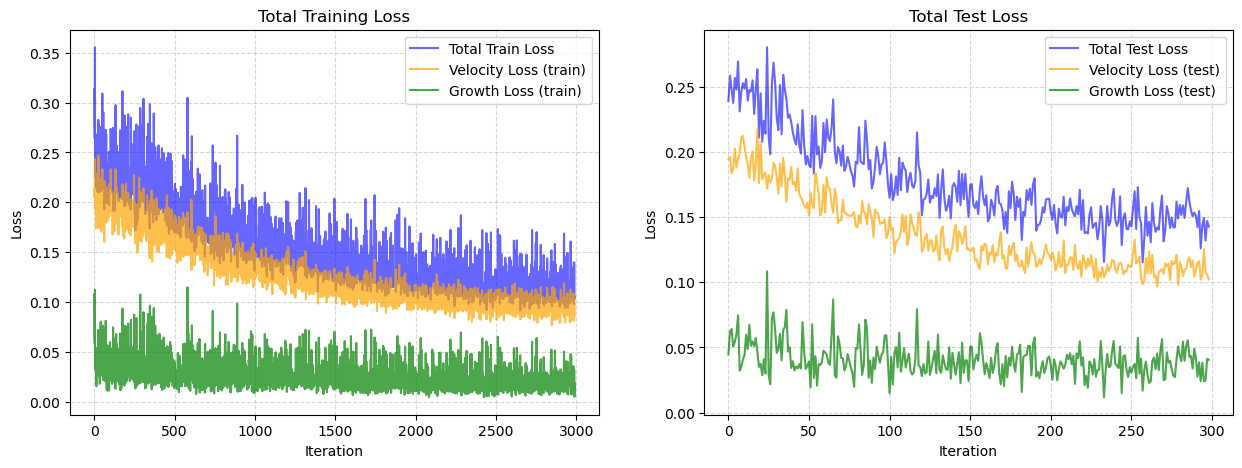

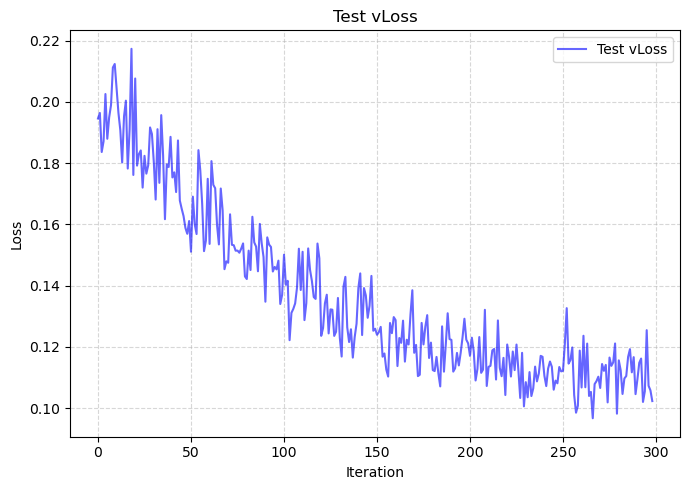

In [47]:
from src.evaluate import draw_loss
load_path = "./results/checkpoints/norman/test_epoch_3000.pt"
draw_loss(load_path,eval_interval = 10,cut = 10)

## inference & evalutaion

In [51]:
print(adata.var["gene_name"])

gene_id
ENSG00000239945    RP11-34P13.8
ENSG00000223764     RP11-54O7.3
ENSG00000187634          SAMD11
ENSG00000187642           PERM1
ENSG00000188290            HES4
                       ...     
ENSG00000198786          MT-ND5
ENSG00000198695          MT-ND6
ENSG00000198727          MT-CYB
ENSG00000273554      AC136616.1
ENSG00000278633      AC023491.2
Name: gene_name, Length: 5045, dtype: category
Categories (5045, object): ['A2M', 'A2M-AS1', 'A2ML1', 'AAK1', ..., 'ZSWIM1', 'ZSWIM4', 'ZSWIM8', 'ZYX']


In [55]:
from src.evaluate import run_batch_inference
target_genes = test_gene
# target_genes = ['CDCA2', 'DHX36', 'TMSB10']
                
n_particles = 5000
all_indices = np.arange(adata_control.n_obs)
rng = np.random.default_rng(42)
indices = rng.choice(all_indices, n_particles, replace=False) if n_particles < len(all_indices) else all_indices
adata_source = torch.tensor(adata_control.obsm[sample_rep_scaled][indices], dtype=torch.float32, device=device)

results_embedding = run_batch_inference(
    model=model,
    adata_source=adata_source,
    adata_conditions=adata_test,
    target_conditions=target_genes,
    condition_keys = condition_keys,
    embedding_key = condition_rep_keys,
    source_rep = sample_rep_scaled,
    n_steps = 50, # ode step
    device = device,
    random_seed = 42
)

100%|██████████| 27/27 [02:46<00:00,  6.15s/it]


In [54]:
from src.evaluate import run_batch_inference
from src.evaluate import batch_reconstruct_pca, batch_reconstruct_scvi, batch_reconstruct_flatvi
from src.evaluate.evals import *
from src.evaluate import evaluate_latent,evaluate_population_average,evaluate_population_distribution

In [56]:
from src.evaluate import batch_reconstruct_pca, batch_reconstruct_scvi

# 我们可以reconstruct出原始基因表达
# 这里 m应该咋用呢
if sample_rep == "X_pca":
    results_genes = batch_reconstruct_pca(
        inference_results=results_embedding,  
        ref_adata=adata_control        
    )
elif sample_rep == "X_scVI":
    batch_data = adata_control.obs['_scvi_batch'].values[indices]
    results_genes1 = batch_reconstruct_scvi(
        inference_results=results_embedding,
        scvi_model=model_ref,  # 传入模型
        target_library_size=1e4, # 输出将被标准化到 10,000 counts
        batch_idx = torch.tensor(adata_control.obs['_scvi_batch'].values[indices], dtype=torch.long, device=device).unsqueeze(1) # 如果希望都投射到第0个batch 可以直接不传或者传None
    )


  0%|          | 0/27 [00:00<?, ?it/s]/lustre/home/2300017748/.conda/envs/ProGen/lib/python3.10/site-packages/anndata/_core/anndata.py:381: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(
  4%|▎         | 1/27 [00:00<00:20,  1.26it/s]/lustre/home/2300017748/.conda/envs/ProGen/lib/python3.10/site-packages/anndata/_core/anndata.py:381: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(
/lustre/home/2300017748/.conda/envs/ProGen/lib/python3.10/site-packages/anndata/_core/anndata.py:381: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(
/lustre/home/2300017748/.conda/envs/ProGen/lib/python3.10/site-packages/anndata/_core/anndata.py:381: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(
 15%|█▍        | 4/27 [00:00<00:04,  5.47it/s]/lustre/home/2300017748/.conda/envs/ProGen/lib/python3.10/site-pac

In [57]:
#print(results_embedding)
print(results_genes)

{'ctrl+SLC38A2': AnnData object with n_obs × n_vars = 5000 × 5045
    obs: 'condition', 'mass'
    uns: 'reconstruction_params', 'FEV+ISL2': AnnData object with n_obs × n_vars = 5000 × 5045
    obs: 'condition', 'mass'
    uns: 'reconstruction_params', 'CEBPE+PTPN12': AnnData object with n_obs × n_vars = 5000 × 5045
    obs: 'condition', 'mass'
    uns: 'reconstruction_params', 'C3orf72+FOXL2': AnnData object with n_obs × n_vars = 5000 × 5045
    obs: 'condition', 'mass'
    uns: 'reconstruction_params', 'CEBPB+MAPK1': AnnData object with n_obs × n_vars = 5000 × 5045
    obs: 'condition', 'mass'
    uns: 'reconstruction_params', 'LYL1+ctrl': AnnData object with n_obs × n_vars = 5000 × 5045
    obs: 'condition', 'mass'
    uns: 'reconstruction_params', 'FOXA3+FOXF1': AnnData object with n_obs × n_vars = 5000 × 5045
    obs: 'condition', 'mass'
    uns: 'reconstruction_params', 'ctrl+TGFBR2': AnnData object with n_obs × n_vars = 5000 × 5045
    obs: 'condition', 'mass'
    uns: 'reconstr

In [ ]:
from src.evaluate import plot_perturbation_umap
plot_perturbation_umap(
    results_embedding=results_embedding,
    adata_control=adata_control,
    adata_conditions=adata_train, # 或者 adata_test
    target_genes=target_genes,
    control_indices=indices, 
    rep_key=sample_rep_scaled
)

In [ ]:
plot_perturbation_umap(
    results_embedding=results_embedding,
    adata_control=adata_control,
    adata_conditions=adata_test, # 或者 adata_test
    target_genes=target_genes,
    control_indices=indices, 
    rep_key=sample_rep_scaled
)

In [22]:
if sample_rep_scaled == "X_scVI":
    sc.pp.normalize_total(adata_control, target_sum=1e4)
    sc.pp.normalize_total(adata_train, target_sum=1e4)
    sc.pp.normalize_total(adata_test, target_sum=1e4)


# 可以使用以下函数复原，可以返回去掉batch信息后的归一化count
# 但是会导致返回的不再是一个稀疏矩阵，导致内存爆掉
# 应对方法可能有:只看某些基因等等
# temp = model_ref.get_normalized_expression(
#         adata=adata, 
#         library_size="latent", 
#         n_samples=10,         
#         return_mean=True,
#         transform_batch= ？？ 
#     )

--- Analyzing CDCA2 ---


/lustre/home/2300012136/mycode/DynamicVirtualCell/WFRFM/src/evaluate/evals.py:161: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  adata_merged = subset_ctrl[:, common_genes].concatenate(subset_real[:, common_genes])


Top DEGs found: ['CDCA2', 'CHCHD2', 'TUBB2A', 'ZNF850', 'TAGLN']


/lustre/home/2300012136/mycode/DynamicVirtualCell/WFRFM/src/evaluate/evals.py:251: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(


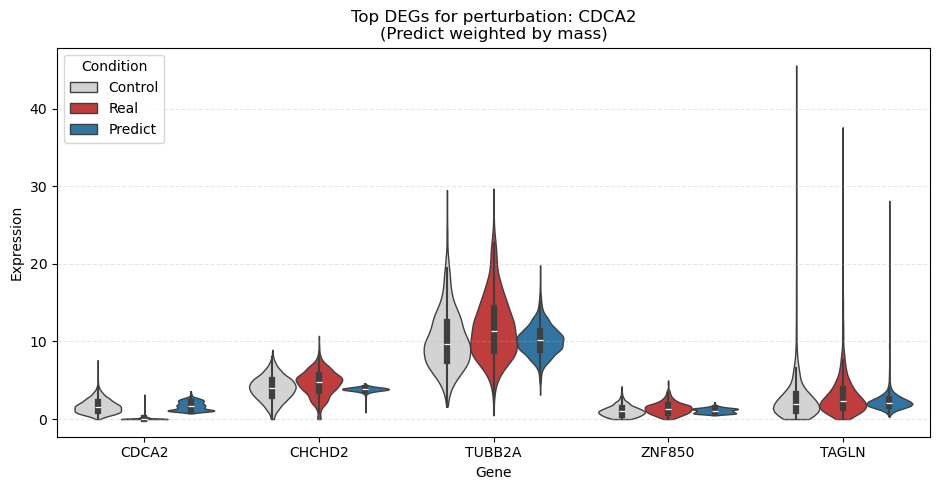

--- Analyzing DHX36 ---


/lustre/home/2300012136/mycode/DynamicVirtualCell/WFRFM/src/evaluate/evals.py:161: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  adata_merged = subset_ctrl[:, common_genes].concatenate(subset_real[:, common_genes])


Top DEGs found: ['DHX36', 'RYBP', 'LDB1', 'MTA3', 'DYNLL2']


/lustre/home/2300012136/mycode/DynamicVirtualCell/WFRFM/src/evaluate/evals.py:251: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(


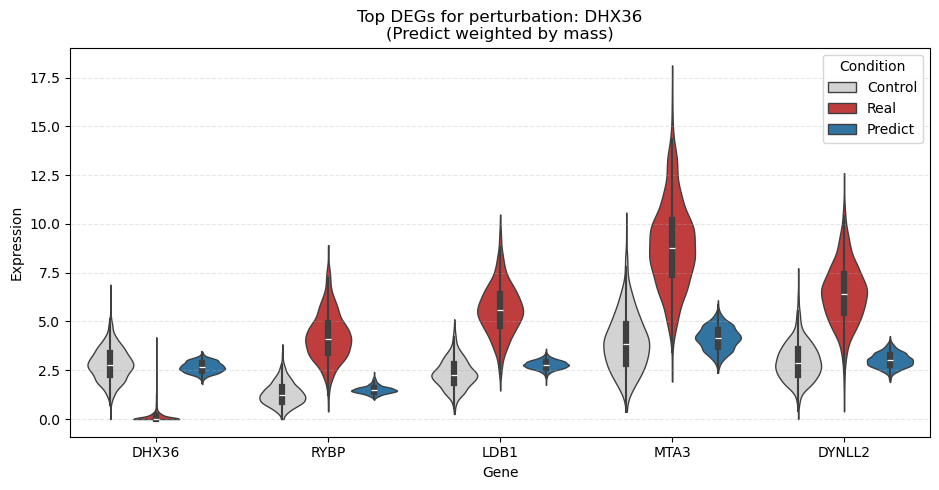

--- Analyzing TMSB10 ---


/lustre/home/2300012136/mycode/DynamicVirtualCell/WFRFM/src/evaluate/evals.py:161: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  adata_merged = subset_ctrl[:, common_genes].concatenate(subset_real[:, common_genes])


Top DEGs found: ['TMSB10', 'ACTL8', 'ACSS2', 'MVD', 'HMGCS1']


/lustre/home/2300012136/mycode/DynamicVirtualCell/WFRFM/src/evaluate/evals.py:251: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(


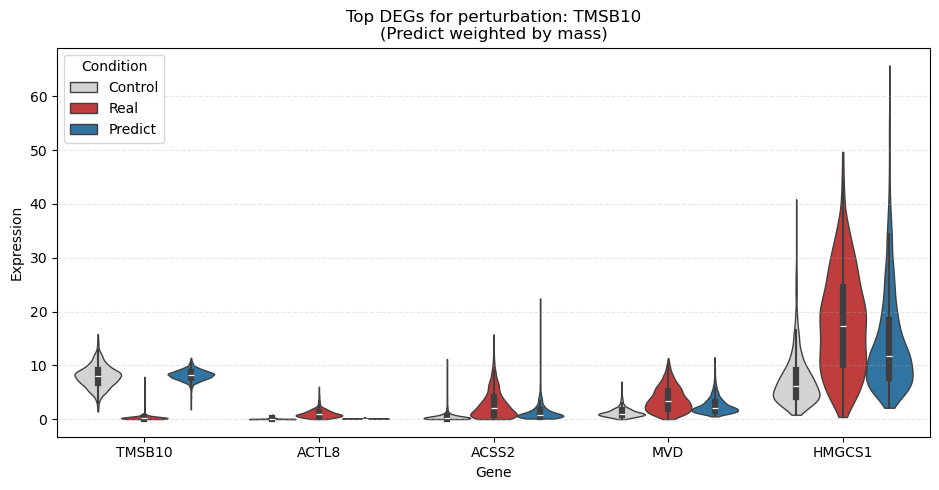

--- Analyzing KAT2A ---


/lustre/home/2300012136/mycode/DynamicVirtualCell/WFRFM/src/evaluate/evals.py:161: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  adata_merged = subset_ctrl[:, common_genes].concatenate(subset_real[:, common_genes])


Top DEGs found: ['KAT2A', 'NODAL', 'ITGB5', 'CRABP2', 'NES']


/lustre/home/2300012136/mycode/DynamicVirtualCell/WFRFM/src/evaluate/evals.py:251: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(


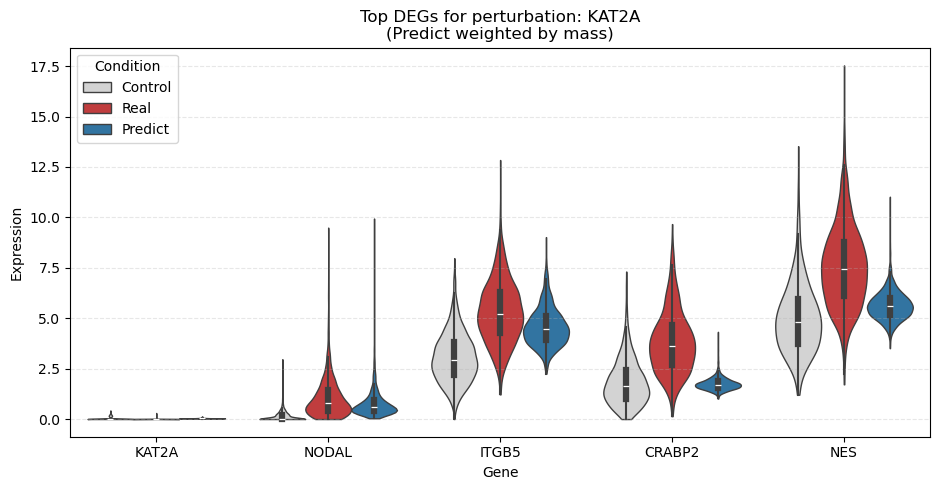

--- Analyzing PHF14 ---


/lustre/home/2300012136/mycode/DynamicVirtualCell/WFRFM/src/evaluate/evals.py:161: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  adata_merged = subset_ctrl[:, common_genes].concatenate(subset_real[:, common_genes])


Top DEGs found: ['PHF14', 'CRABP2', 'NES', 'RND2', 'SEPTIN11']


/lustre/home/2300012136/mycode/DynamicVirtualCell/WFRFM/src/evaluate/evals.py:251: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(


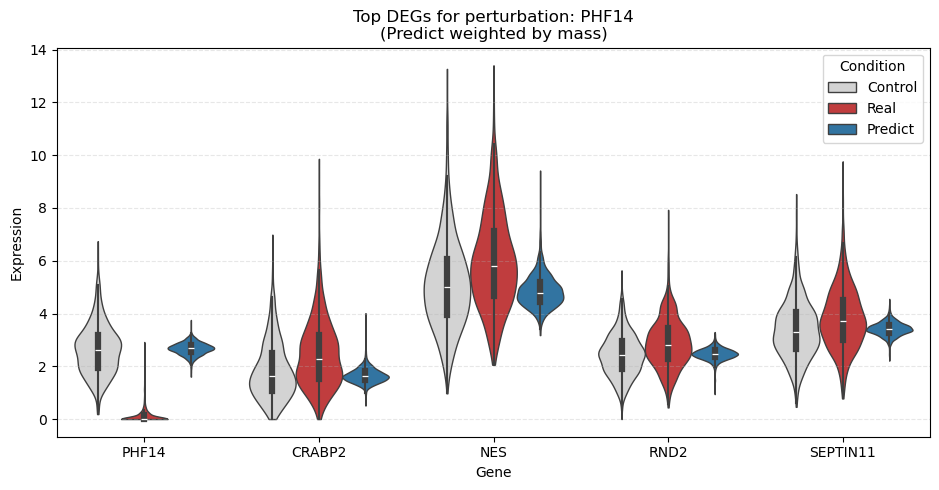

--- Analyzing KLF10 ---


/lustre/home/2300012136/mycode/DynamicVirtualCell/WFRFM/src/evaluate/evals.py:161: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  adata_merged = subset_ctrl[:, common_genes].concatenate(subset_real[:, common_genes])


Top DEGs found: ['KLF10', 'ALDH6A1', 'HK2', 'KLF15', 'ABAT']


/lustre/home/2300012136/mycode/DynamicVirtualCell/WFRFM/src/evaluate/evals.py:251: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(


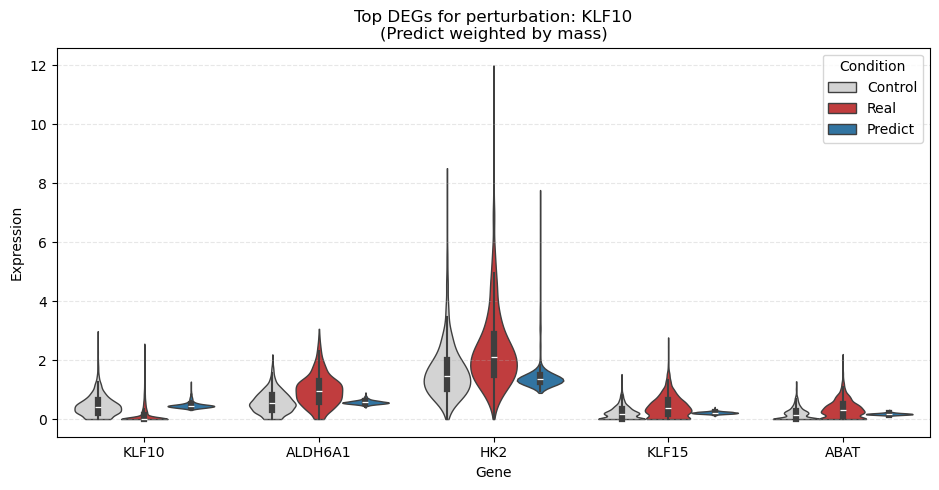

--- Analyzing KDM1A ---


/lustre/home/2300012136/mycode/DynamicVirtualCell/WFRFM/src/evaluate/evals.py:161: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  adata_merged = subset_ctrl[:, common_genes].concatenate(subset_real[:, common_genes])


Top DEGs found: ['KDM1A', 'VIM', 'NRK', 'SPP1', 'APELA']


/lustre/home/2300012136/mycode/DynamicVirtualCell/WFRFM/src/evaluate/evals.py:251: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(


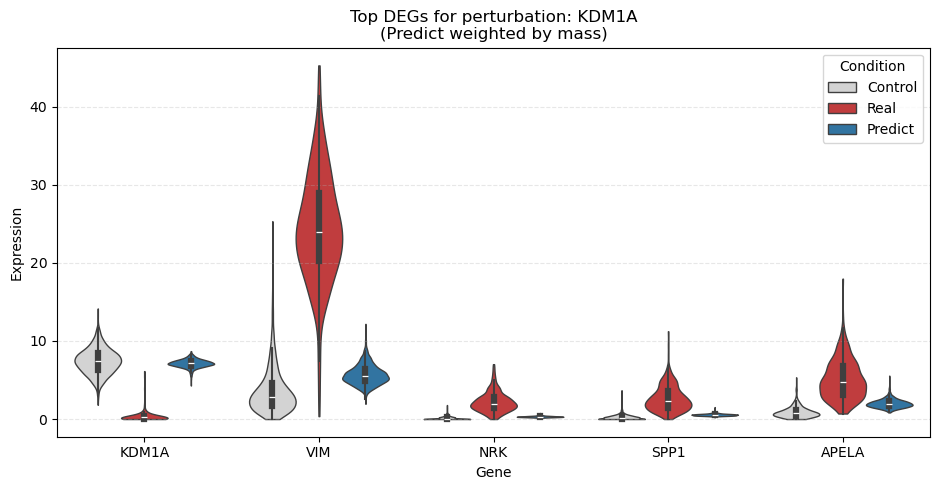

In [23]:
from src.evaluate import plot_top_degs_violin
for target in target_genes: # ['CDCA2', 'DHX36', 'TMSB10']
    plot_top_degs_violin(
        reconstructed_data=results_genes1,
        adata_control=adata_control,
        adata_real=adata_train,
        target_gene=target,
        top_n=4 # 展示 Target + Top 4 下游基因
    )

--- Analyzing CDCA2 ---


/lustre/home/2300012136/mycode/DynamicVirtualCell/WFRFM/src/evaluate/evals.py:161: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  adata_merged = subset_ctrl[:, common_genes].concatenate(subset_real[:, common_genes])


Top DEGs found: ['CDCA2', 'ZNF850', 'GAL', 'SIX4', 'DACT1']


/lustre/home/2300012136/mycode/DynamicVirtualCell/WFRFM/src/evaluate/evals.py:251: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(


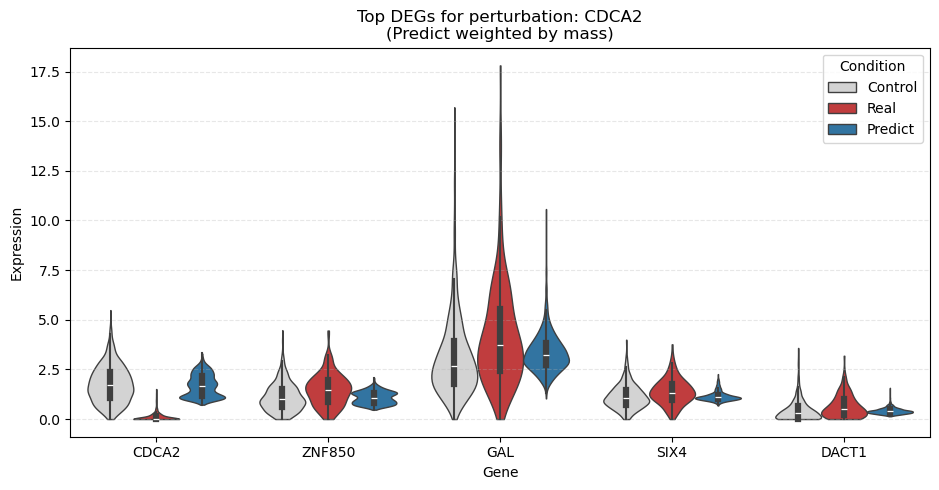

--- Analyzing DHX36 ---


/lustre/home/2300012136/mycode/DynamicVirtualCell/WFRFM/src/evaluate/evals.py:161: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  adata_merged = subset_ctrl[:, common_genes].concatenate(subset_real[:, common_genes])


Top DEGs found: ['DHX36', 'LDB1', 'DYNLL2', 'RYBP', 'MTA3']


/lustre/home/2300012136/mycode/DynamicVirtualCell/WFRFM/src/evaluate/evals.py:251: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(


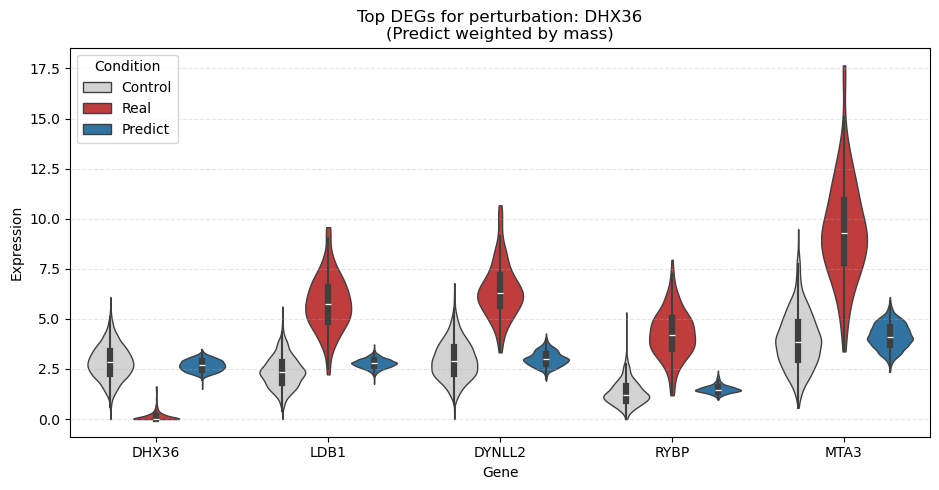

--- Analyzing TMSB10 ---


/lustre/home/2300012136/mycode/DynamicVirtualCell/WFRFM/src/evaluate/evals.py:161: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  adata_merged = subset_ctrl[:, common_genes].concatenate(subset_real[:, common_genes])


Top DEGs found: ['TMSB10', 'ACTL8', 'HMGCS1', 'CYB5B', 'ACSS2']


/lustre/home/2300012136/mycode/DynamicVirtualCell/WFRFM/src/evaluate/evals.py:251: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(


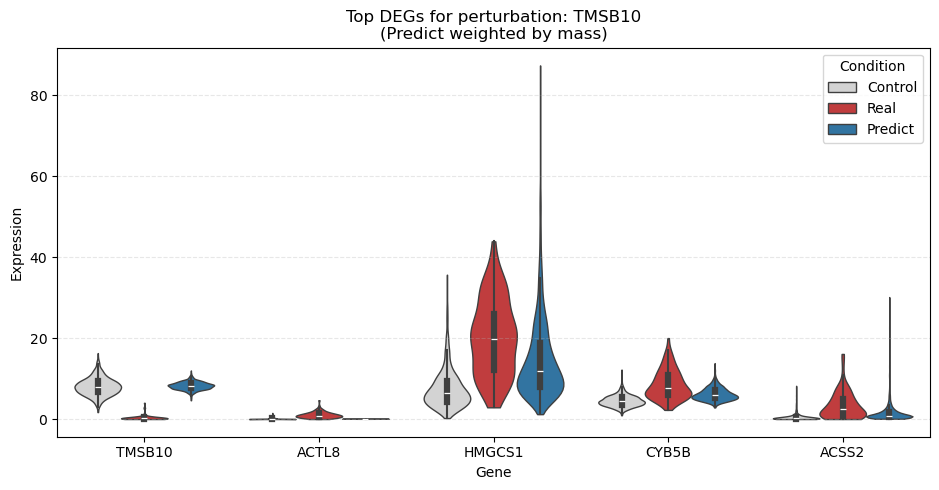

--- Analyzing KAT2A ---


/lustre/home/2300012136/mycode/DynamicVirtualCell/WFRFM/src/evaluate/evals.py:161: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  adata_merged = subset_ctrl[:, common_genes].concatenate(subset_real[:, common_genes])


Top DEGs found: ['KAT2A', 'NODAL', 'ITGB5', 'CRABP2', 'OCIAD2']


/lustre/home/2300012136/mycode/DynamicVirtualCell/WFRFM/src/evaluate/evals.py:251: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(


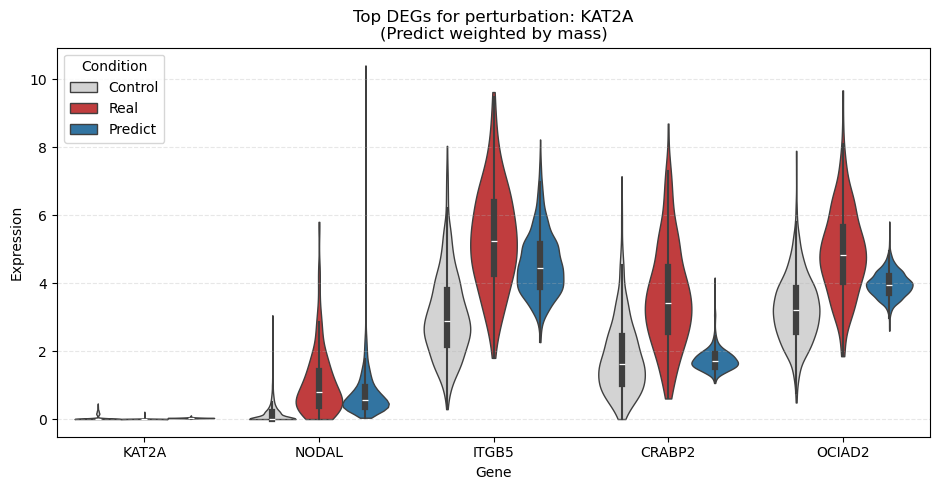

--- Analyzing PHF14 ---


/lustre/home/2300012136/mycode/DynamicVirtualCell/WFRFM/src/evaluate/evals.py:161: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  adata_merged = subset_ctrl[:, common_genes].concatenate(subset_real[:, common_genes])


Top DEGs found: ['PHF14', 'RND2', 'NES', 'SPP1', 'CRABP2']


/lustre/home/2300012136/mycode/DynamicVirtualCell/WFRFM/src/evaluate/evals.py:251: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(


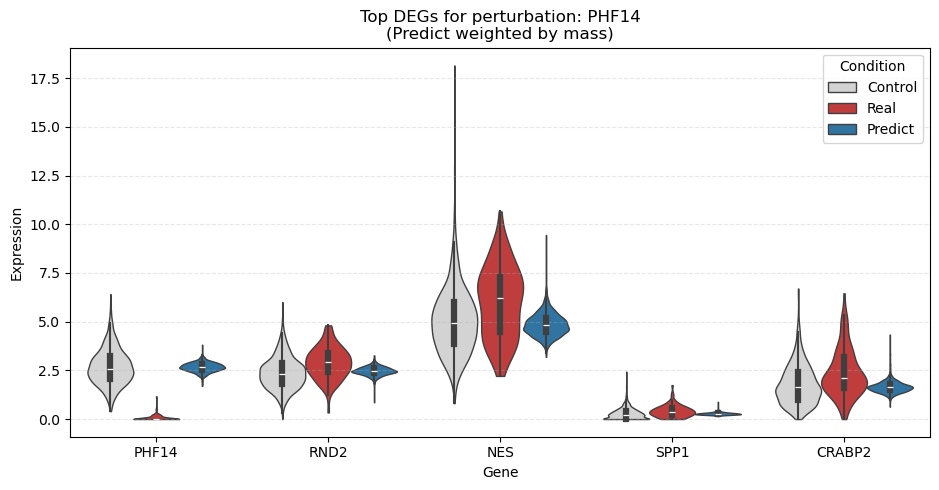

--- Analyzing KLF10 ---


/lustre/home/2300012136/mycode/DynamicVirtualCell/WFRFM/src/evaluate/evals.py:161: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  adata_merged = subset_ctrl[:, common_genes].concatenate(subset_real[:, common_genes])


Top DEGs found: ['KLF10', 'ALDH6A1', 'KLF15', 'HK2', 'ABAT']


/lustre/home/2300012136/mycode/DynamicVirtualCell/WFRFM/src/evaluate/evals.py:251: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(


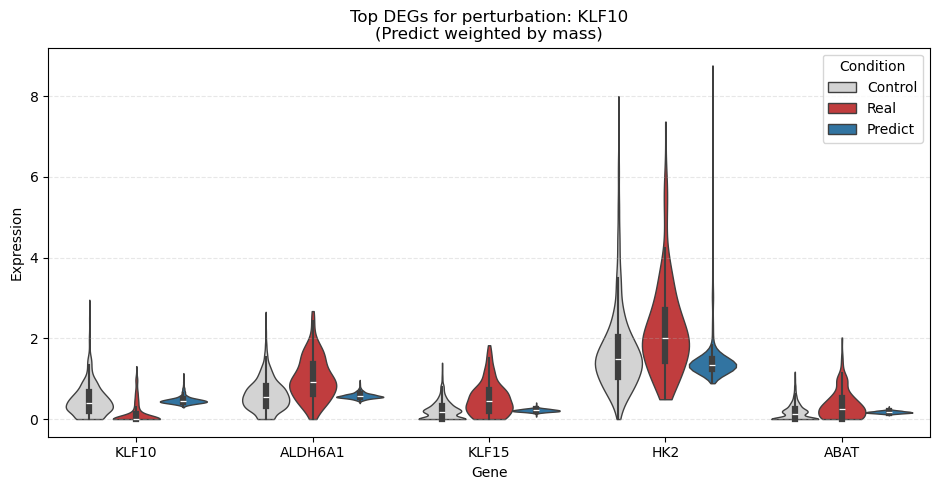

--- Analyzing KDM1A ---


/lustre/home/2300012136/mycode/DynamicVirtualCell/WFRFM/src/evaluate/evals.py:161: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  adata_merged = subset_ctrl[:, common_genes].concatenate(subset_real[:, common_genes])


Top DEGs found: ['KDM1A', 'VIM', 'NRK', 'SPP1', 'APELA']


/lustre/home/2300012136/mycode/DynamicVirtualCell/WFRFM/src/evaluate/evals.py:251: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(


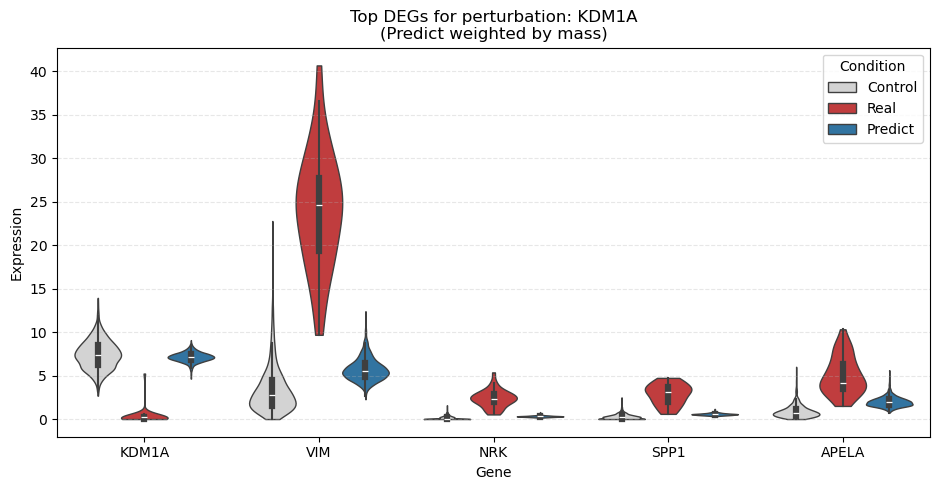

In [24]:
for target in target_genes: # ['CDCA2', 'DHX36', 'TMSB10']
    plot_top_degs_violin(
        reconstructed_data=results_genes1,
        adata_control=adata_control,
        adata_real=adata_test,
        target_gene=target,
        top_n=4 # 展示 Target + Top 4 下游基因
    )

In [ ]:
def plot_perturbation_umap_optimized(
    results_embedding, 
    adata_control, 
    adata_conditions, 
    target_genes, 
    control_indices,
    condition_key="target_gene",
    rep_key="X_pca_scaled",
    n_neighbors=30
):
    # --- 1. 预计算 Control 的 UMAP (基准流形) ---
    print("Pre-computing Control UMAP manifold...")
    # 提取 Control embedding
    X_ctrl_emb = adata_control.obsm[rep_key][control_indices]
    
    # 创建专门用于计算流形的 AnnData
    adata_base = sc.AnnData(X=X_ctrl_emb)
    sc.pp.neighbors(adata_base, n_neighbors=n_neighbors, use_rep='X')
    sc.tl.umap(adata_base)
    
    # 获取 Control 的 UMAP 坐标，这将作为背景在所有图中保持不变
    umap_ctrl_coords = adata_base.obsm['X_umap']
    
    # 定义一个简单的投影函数 (将新点映射到现有 UMAP 空间)
    # 这里使用 scanpy.tl.ingest 的逻辑，或者简单地重新拼接计算 (但在循环里为了效率，我们采用 trick)
    # 如果为了绝对严谨，应该用 sc.tl.ingest。
    # 这里为了代码复用你原本的逻辑，我展示如何通过 "ingest" 避免流形抖动。
    
    # 实际上，为了展示 Predict 是否“跑到了正确的位置”，
    # 最公平的方法是：把 Control, Real, Predict 拼在一起，重新算一次 UMAP。
    # 但为了避免每个基因都算，我们可以利用 adata_base 已经算好的 neighbor graph。
    # 不过，考虑到单细胞数据的复杂性，针对每个基因单独算一次 UMAP (Joint UMAP) 
    # 其实在可视化上是最诚实的（展示混合程度）。
    
    # 所以，保留你的逻辑，但建议把 UMAP 参数固定，并加入 random_state 保证可复现
    
    for gene in target_genes:
        if gene not in results_embedding:
            continue
            
        print(f"Processing {gene}...")
        
        # ... (获取数据代码不变) ...
        subset = adata_conditions[adata_conditions.obs[condition_key] == gene]
        if subset.n_obs == 0: continue
            
        idx_real = np.random.choice(range(subset.n_obs), size=min(subset.n_obs, len(control_indices)), replace=False)
        X_real = subset.obsm[rep_key][idx_real]
        
        res = results_embedding[gene]
        X_pred = res['z_pred']
        m_pred = res['m_pred'].flatten()
        
        # --- 优化：使用 concat 而不是 vstack (保留 AnnData 格式方便处理) ---
        X_combined = np.vstack([X_ctrl_emb, X_real, X_pred])
        adata_vis = sc.AnnData(X=X_combined)
        
        # 给定 labels
        labels = ['Control'] * len(X_ctrl_emb) + ['Real'] * len(X_real) + ['Predict'] * len(X_pred)
        adata_vis.obs['condition'] = labels
        adata_vis.obs['condition'] = adata_vis.obs['condition'].astype('category')
        
        # 关键：设置 random_state 减少抖动
        sc.pp.neighbors(adata_vis, n_neighbors=n_neighbors, use_rep='X')
        sc.tl.umap(adata_vis, random_state=42) 
        
        umap_coords = adata_vis.obsm['X_umap']
        
        # 切片
        n_c = len(X_ctrl_emb)
        n_r = len(X_real)
        u_c = umap_coords[:n_c]
        u_r = umap_coords[n_c:n_c+n_r]
        u_p = umap_coords[n_c+n_r:]
        
        # --- 绘图部分 (优化 Alpha 混合逻辑) ---
        fig, axes = plt.subplots(1, 2, figsize=(12, 5))
        
        # Plot 1
        ax = axes[0]
        # 调整顺序：先画 Control，再画 Predict (透明)，最后画 Real (实心点)，或者 Real 在下 Predict 在上
        # 通常建议：Control -> Real -> Predict (看 Predict 是否覆盖 Real)
        
        ax.scatter(u_c[:, 0], u_c[:, 1], c='lightgrey', s=10, label='Control', alpha=0.3, rasterized=True, edgecolors='none')
        ax.scatter(u_r[:, 0], u_r[:, 1], c='#d62728', s=15, label='Real', alpha=0.6, rasterized=True, edgecolors='none')
        
        # 处理 Alpha
        m_norm = (m_pred - m_pred.min()) / (m_pred.max() - m_pred.min() + 1e-9)
        # 稍微非线性一点，让低的更低，高的更高
        alphas = np.clip(m_norm, 0.02, 0.9) 
        
        # 构建 RGBA
        base_color = plt.cm.tab10(0) # Blue
        rgba = np.zeros((len(X_pred), 4))
        rgba[:, :3] = base_color[:3]
        rgba[:, 3] = alphas
        
        ax.scatter(u_p[:, 0], u_p[:, 1], c=rgba, s=15, label='Predict', rasterized=True, edgecolors='none')
        
        ax.legend(markerscale=3, frameon=False)
        ax.set_title(f"Embedding Space: {gene}")
        ax.axis('off') # 去掉边框更美观
        
        # Plot 2 (Mass)
        ax = axes[1]
        ax.scatter(u_c[:, 0], u_c[:, 1], c='lightgrey', s=5, alpha=0.1, rasterized=True)
        sc_plot = ax.scatter(u_p[:, 0], u_p[:, 1], c=m_pred, cmap='viridis', s=15, rasterized=True, edgecolors='none')
        plt.colorbar(sc_plot, ax=ax, label='Predicted Mass', fraction=0.046, pad=0.04)
        ax.set_title("Mass Distribution")
        ax.axis('off')
        
        plt.tight_layout()
        plt.show()

In [ ]:
plot_perturbation_umap_optimized(
    results_embedding=results_embedding,
    adata_control=adata_control,
    adata_conditions=adata_train, # 或者 adata_test
    target_genes=target_genes,
    control_indices=indices, 
    rep_key=sample_rep_scaled
)

=== Mass Statistics for CDCA2 prediction ===
Mean Mass: 0.0424
Max  Mass: 0.0465
Min  Mass: 0.0336
Std  Mass: 0.0005


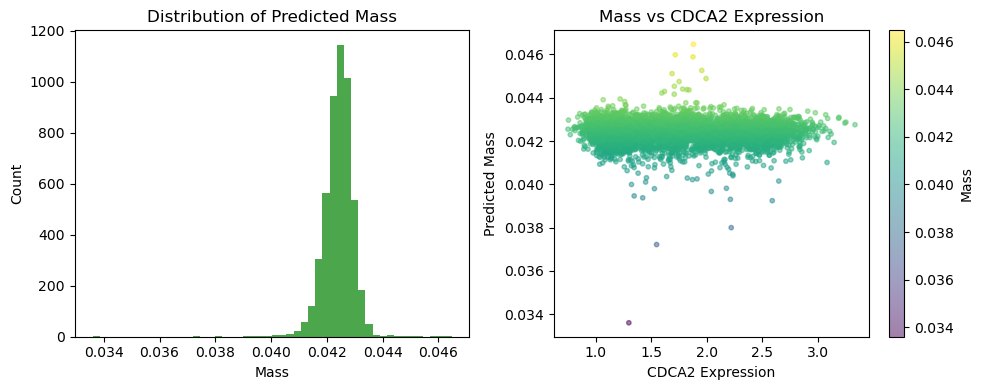

=== Mass Statistics for DHX36 prediction ===
Mean Mass: 0.0342
Max  Mass: 0.0471
Min  Mass: 0.0299
Std  Mass: 0.0018


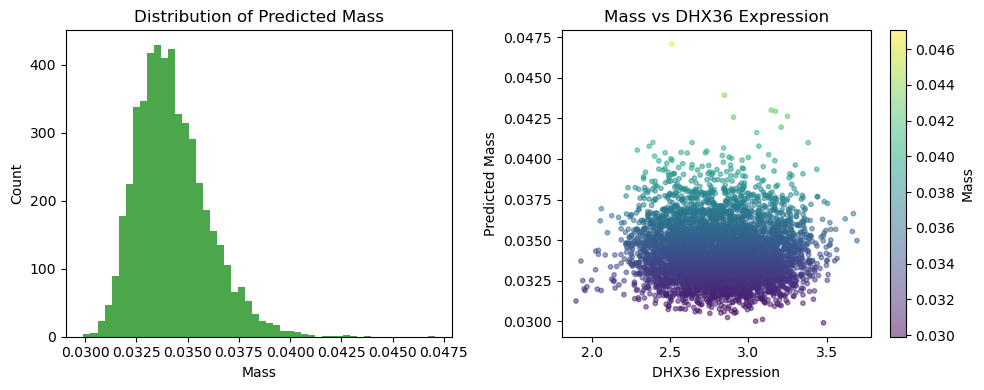

=== Mass Statistics for TMSB10 prediction ===
Mean Mass: 0.0219
Max  Mass: 0.0260
Min  Mass: 0.0174
Std  Mass: 0.0006


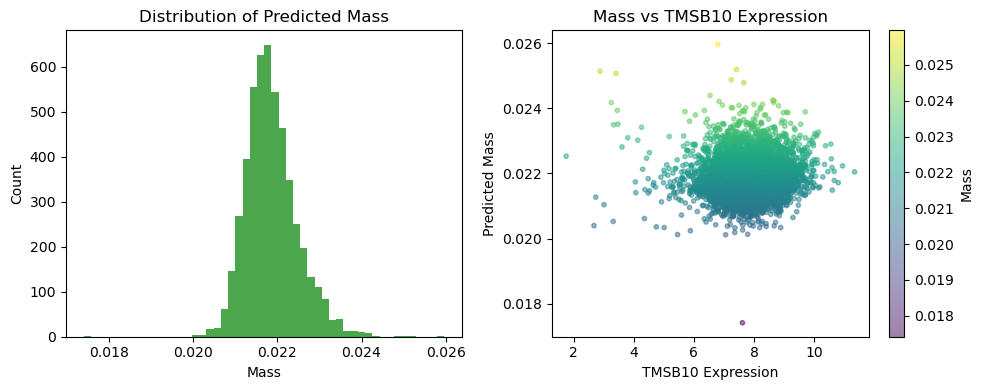

=== Mass Statistics for KAT2A prediction ===
Mean Mass: 0.0512
Max  Mass: 0.0600
Min  Mass: 0.0400
Std  Mass: 0.0022


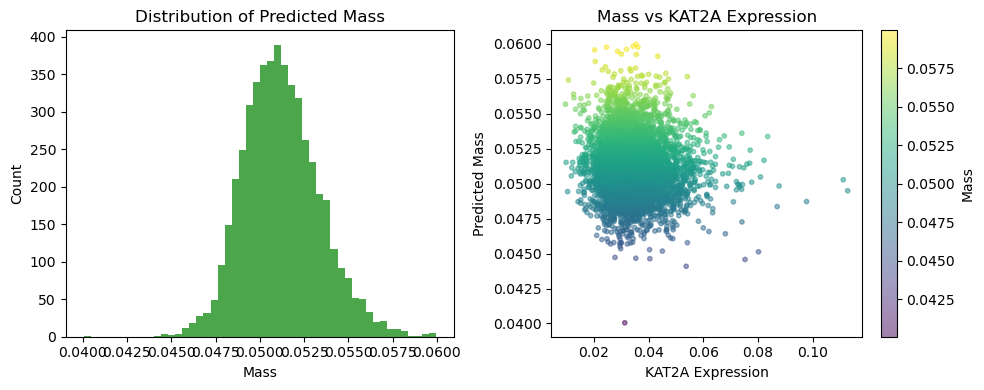

=== Mass Statistics for PHF14 prediction ===
Mean Mass: 0.0228
Max  Mass: 0.0255
Min  Mass: 0.0188
Std  Mass: 0.0003


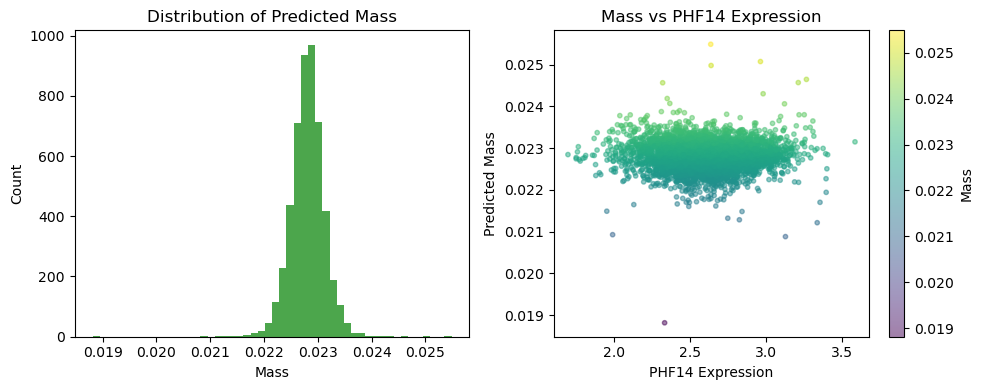

=== Mass Statistics for KLF10 prediction ===
Mean Mass: 0.0473
Max  Mass: 0.0526
Min  Mass: 0.0387
Std  Mass: 0.0006


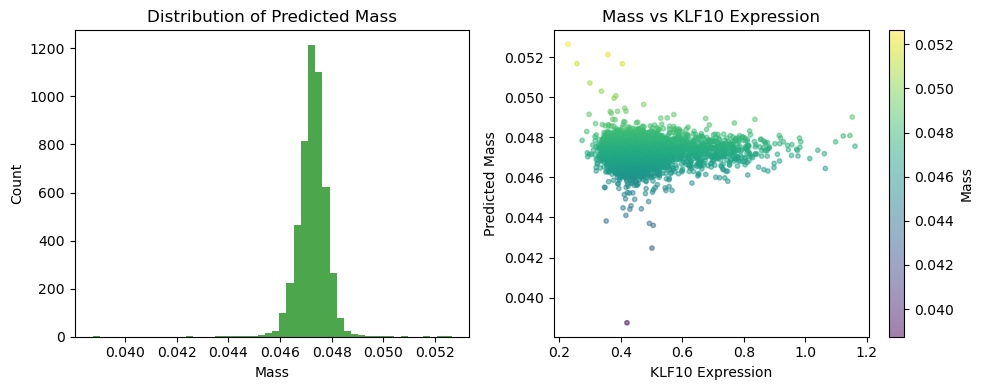

=== Mass Statistics for KDM1A prediction ===
Mean Mass: 0.0093
Max  Mass: 0.0137
Min  Mass: 0.0075
Std  Mass: 0.0006


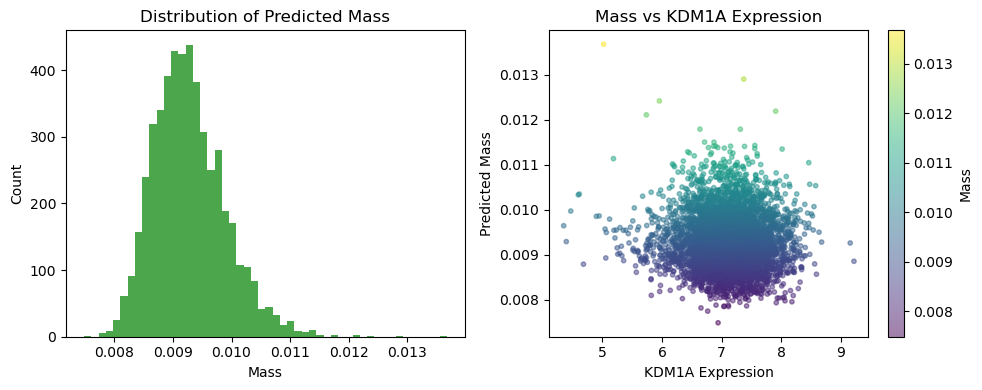

=== Mass Statistics for STAT1 prediction ===
Mean Mass: 0.0604
Max  Mass: 0.0672
Min  Mass: 0.0507
Std  Mass: 0.0007


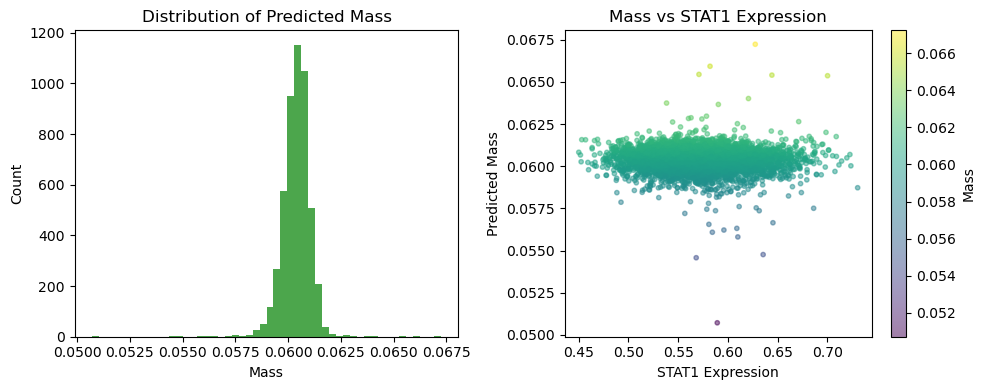

=== Mass Statistics for ACAT2 prediction ===
Mean Mass: 0.0429
Max  Mass: 0.0467
Min  Mass: 0.0317
Std  Mass: 0.0007


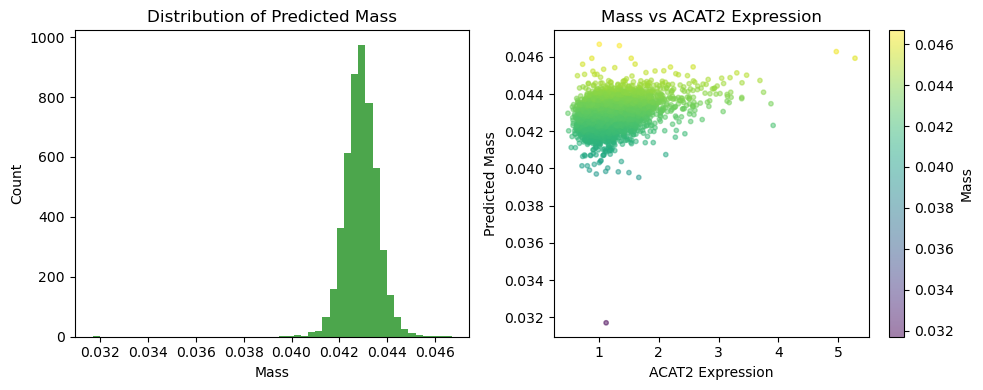

=== Mass Statistics for STX4 prediction ===
Mean Mass: 0.0310
Max  Mass: 0.0336
Min  Mass: 0.0257
Std  Mass: 0.0004


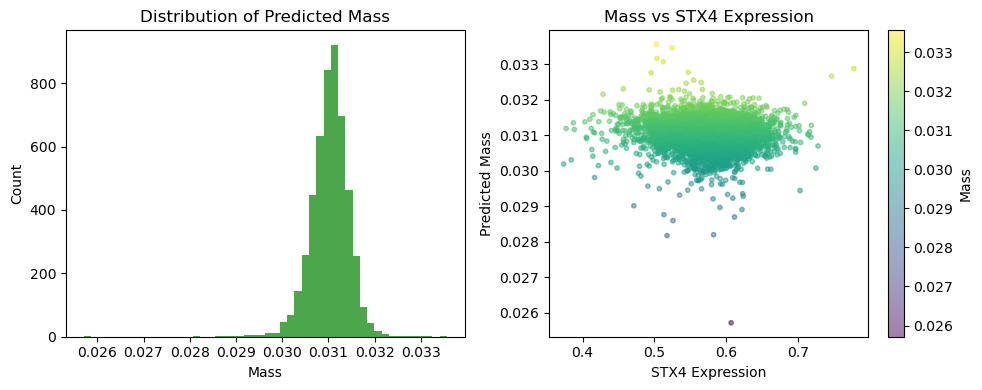

=== Mass Statistics for HMGB2 prediction ===
Mean Mass: 0.0366
Max  Mass: 0.0407
Min  Mass: 0.0338
Std  Mass: 0.0006


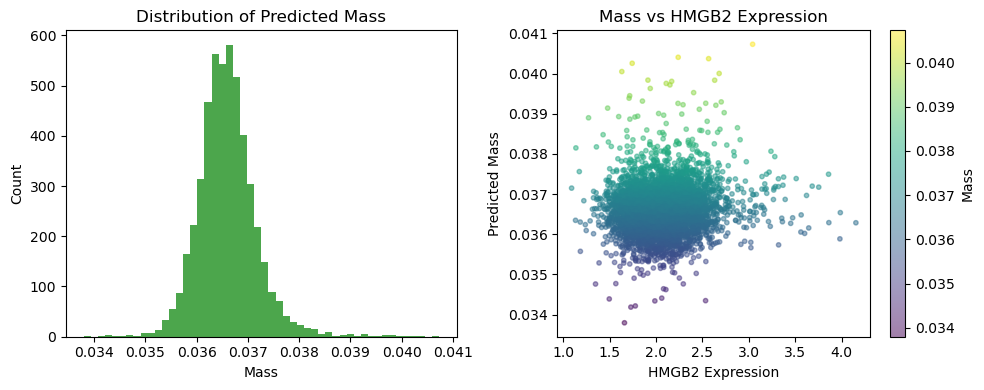

=== Mass Statistics for TADA1 prediction ===
Mean Mass: 0.0957
Max  Mass: 0.1132
Min  Mass: 0.0771
Std  Mass: 0.0037


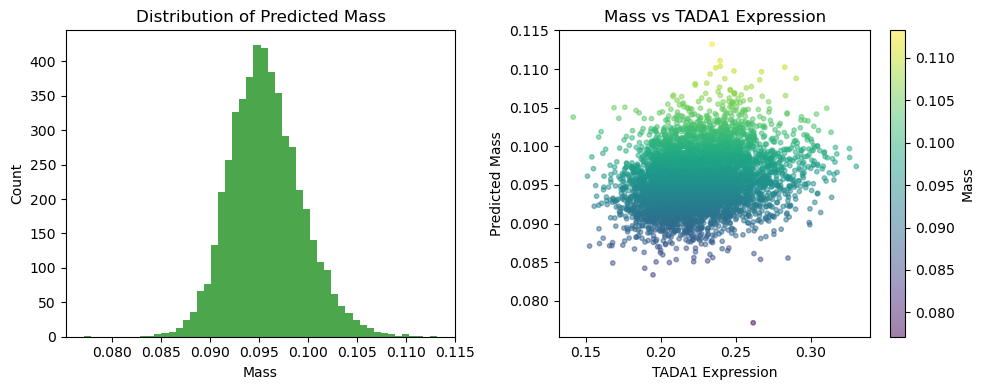

=== Mass Statistics for MTA1 prediction ===
Mean Mass: 0.0352
Max  Mass: 0.0386
Min  Mass: 0.0270
Std  Mass: 0.0005


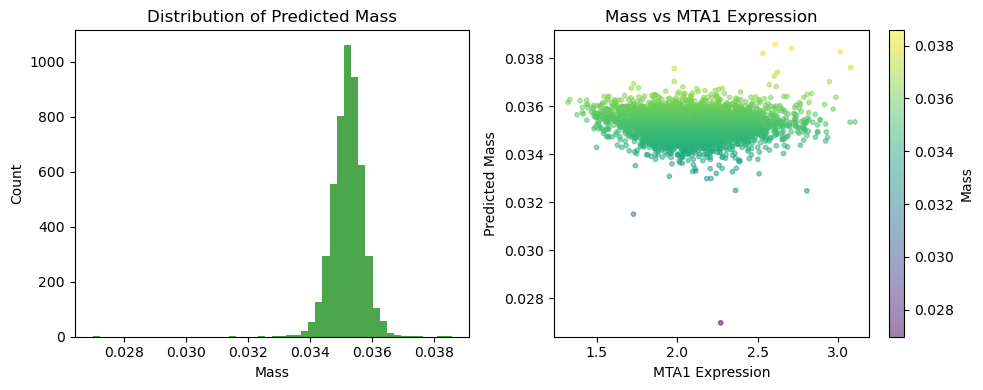

=== Mass Statistics for C1QBP prediction ===
Mean Mass: 0.0182
Max  Mass: 0.0209
Min  Mass: 0.0143
Std  Mass: 0.0003


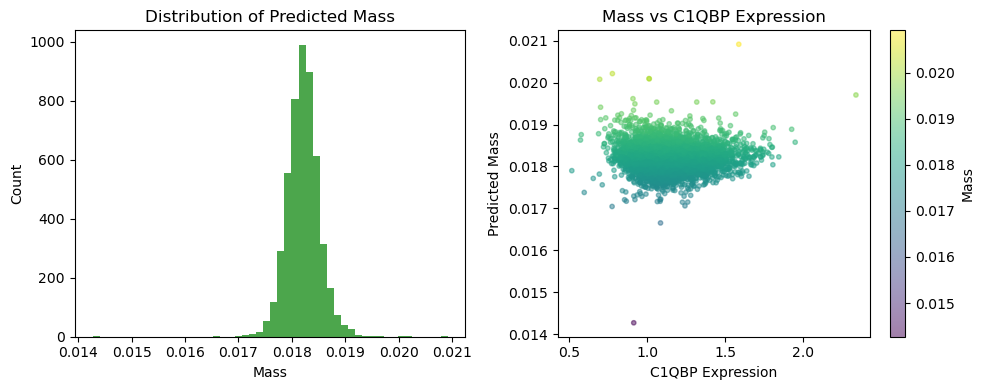

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def diagnose_mass_prediction(pred_adata, gene_name='CDCA2'):
    mass = pred_adata.obs['mass'].values
    expr = pred_adata[:, gene_name].X.flatten() # 或者是 .layers['counts'] 等
    
    # 1. 打印统计数据
    print(f"=== Mass Statistics for {gene_name} prediction ===")
    print(f"Mean Mass: {np.mean(mass):.4f}")
    print(f"Max  Mass: {np.max(mass):.4f}")
    print(f"Min  Mass: {np.min(mass):.4f}")
    print(f"Std  Mass: {np.std(mass):.4f}")
    
    # 2. 绘图：Mass vs Target Gene Expression
    plt.figure(figsize=(10, 4))
    
    # 子图1: Mass 的直方图
    plt.subplot(1, 2, 1)
    plt.hist(mass, bins=50, color='green', alpha=0.7)
    plt.title("Distribution of Predicted Mass")
    plt.xlabel("Mass")
    plt.ylabel("Count")
    
    # 子图2: Mass vs Expression
    plt.subplot(1, 2, 2)
    plt.scatter(expr, mass, alpha=0.5, s=10, c=mass, cmap='viridis')
    plt.title(f"Mass vs {gene_name} Expression")
    plt.xlabel(f"{gene_name} Expression")
    plt.ylabel("Predicted Mass")
    plt.colorbar(label='Mass')
    
    plt.tight_layout()
    plt.show()

# 运行诊断
for gene in target_genes:
    diagnose_mass_prediction(results_genes[gene], gene)